# 2D Cumulative 1D-Scan Viewer

Plots qudi `cummulative_1D-scan` `.dat` files as 2D `imshow` waterfall plots.  
**Configure the file list and line-range sliders in the cell below, then run all cells.**

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ============================================================
#  FILE LIST  – edit paths here
# ============================================================
DATA_DIR = r'Z:\Vlad\heavyIV\espin-254\experiment_I\cold-I\cold-II-ac-E'

FILES = [
    '20260317-1521-56__cummulative_1D-scan_with_a_axes_from_channel_APD1_cw-350MHz-different-powers--minus90V.dat',
    '20260317-1320-56__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-minus20dbM-amplifier.dat',
    '20260317-1321-13__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-minus20dbM-amplifier-immediately-heting.dat',
    '20260317-1323-10__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-immediately-heting-30dbm-notfullsidebands.dat',
    '20260317-1328-22__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-immediately-heting-25dbm-notfullsidebands.dat',
]

# ============================================================
#  LINE RANGE SELECTION  –  per file  [line_start, line_end]
#  Use None to include all lines, e.g. [None, None]
#  Negative indices work too, e.g. [0, -10] skips last 10 lines
# ============================================================
LINE_RANGES = {
    FILES[0]: [None, None],   # all lines
    FILES[1]: [None, None],
    FILES[2]: [None, None],
    FILES[3]: [None, None],
    FILES[4]: [None, None],
}

# ============================================================
#  PLOT SETTINGS
# ============================================================
CMAP          = 'RdBu_r'          # colormap
VMIN          = None           # None = auto; or e.g. 0
VMAX          = None           # None = auto; or e.g. 500
INTERPOLATION = 'none'        # 'none', 'nearest', 'bilinear', …
ASPECT        = 'auto'         # 'auto' or 'equal'
SHOW_SUMMED   = True           # also plot summed spectrum below imshow
FIG_WIDTH     = 14             # figure width in inches
FIG_HEIGHT_PER_FILE = 8        # height per file

print('Settings loaded.')

Settings loaded.


In [13]:
# ============================================================
#  Helper: parse header metadata
# ============================================================
def extract_metadata(filepath):
    meta = {}
    with open(filepath, 'r') as f:
        for line in f:
            if '---- END HEADER ----' in line:
                break
            if line.startswith('# ') and '=' in line:
                k, v = line[2:].strip().split('=', 1)
                meta[k.strip()] = v.strip().strip("'")
    return meta

def parse_float(meta, key, default=None):
    try:
        return float(meta.get(key, default))
    except (TypeError, ValueError):
        return default

def load_scan(fname, line_start=None, line_end=None):
    """Load a .dat scan file, return (data_2d, freq_axis_THz, metadata_dict)."""
    filepath = os.path.join(DATA_DIR, fname)
    meta = extract_metadata(filepath)

    raw = np.loadtxt(filepath, comments='#')
    if raw.ndim == 1:
        raw = raw[np.newaxis, :]

    # Apply line slice
    raw = raw[line_start:line_end, :]

    # Build frequency axis (THz) if wavemeter data is available
    wm_nm = parse_float(meta, 'wavemeter_start_wl_nm')
    a_min = parse_float(meta, 'a axis min', 0.0)
    a_max = parse_float(meta, 'a axis max', 0.0)
    a_res = int(parse_float(meta, 'a axis resolution', raw.shape[1]))
    n_px  = raw.shape[1]

    if wm_nm and wm_nm > 0:
        c  = 299792458.0
        f0 = (c / (wm_nm * 1e-9)) / 1e12
        f_ax = f0 + np.linspace(a_min, a_max, a_res)[:n_px] * 1e6 / 1e12
        x_label = 'Absolute Frequency (THz)'
    else:
        # Fall back to scan-axis channel units (MHz or raw)
        f_ax = np.linspace(a_min, a_max, n_px)
        x_label = 'Scan axis (a.u.)'

    return raw, f_ax, meta, x_label

print('Helper functions defined.')

Helper functions defined.


In [14]:
# ============================================================
#  PREVIEW: print number of lines in each file so you can
#  set LINE_RANGES sensibly
# ============================================================
print(f"{'File':<85} {'Lines':>6} {'Pixels':>7}")
print('-' * 100)
for fname in FILES:
    filepath = os.path.join(DATA_DIR, fname)
    try:
        raw = np.loadtxt(filepath, comments='#')
        if raw.ndim == 1:
            raw = raw[np.newaxis, :]
        print(f"{fname:<85} {raw.shape[0]:>6} {raw.shape[1]:>7}")
    except Exception as e:
        print(f"{fname:<85}  ERROR: {e}")

File                                                                                   Lines  Pixels
----------------------------------------------------------------------------------------------------
20260317-1521-56__cummulative_1D-scan_with_a_axes_from_channel_APD1_cw-350MHz-different-powers--minus90V.dat     30    1000
20260317-1320-56__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-minus20dbM-amplifier.dat    200    1000
20260317-1321-13__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-minus20dbM-amplifier-immediately-heting.dat    200    1000
20260317-1323-10__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-immediately-heting-30dbm-notfullsidebands.dat    200    1000
20260317-1328-22__cummulative_1D-scan_with_a_axes_from_channel_APD1_sidebands-immediately-heting-25dbm-notfullsidebands.dat      6    1000


c:\Users\yy3\Anaconda3\lib\site-packages\ipykernel_launcher.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


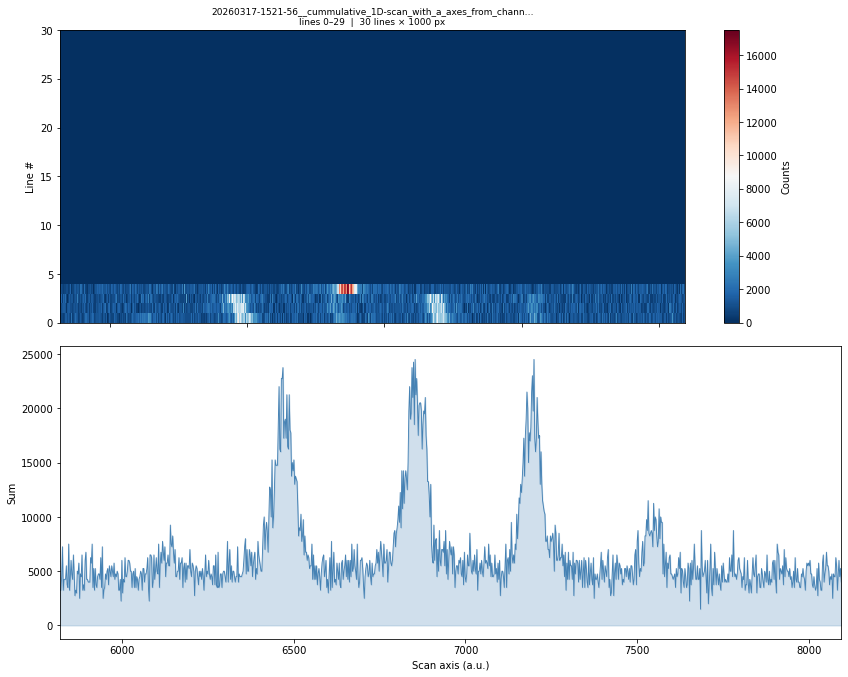

  max=17500  mean=219.67  shape=(30, 1000)


c:\Users\yy3\Anaconda3\lib\site-packages\ipykernel_launcher.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


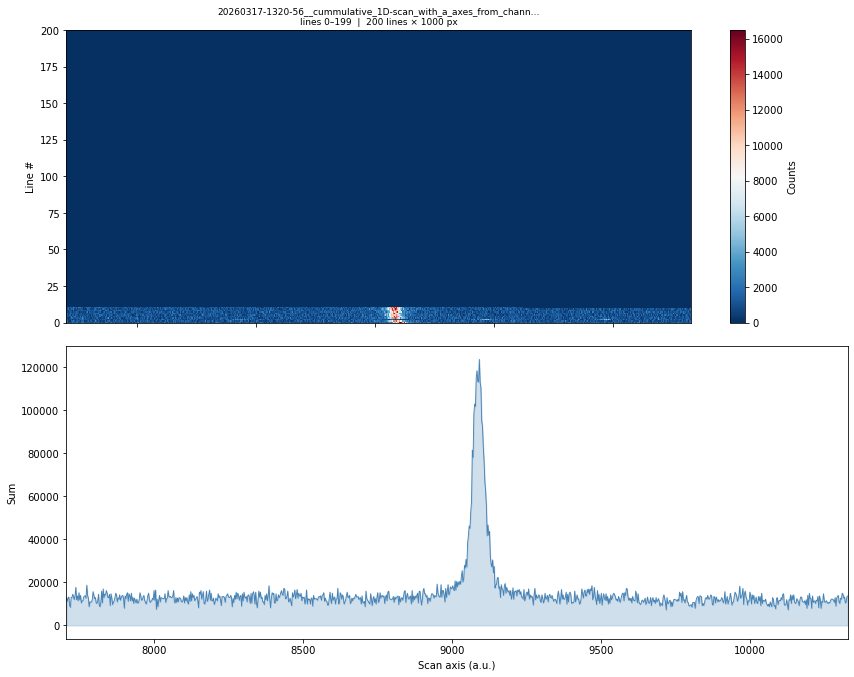

  max=16500  mean=74.48  shape=(200, 1000)


c:\Users\yy3\Anaconda3\lib\site-packages\ipykernel_launcher.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


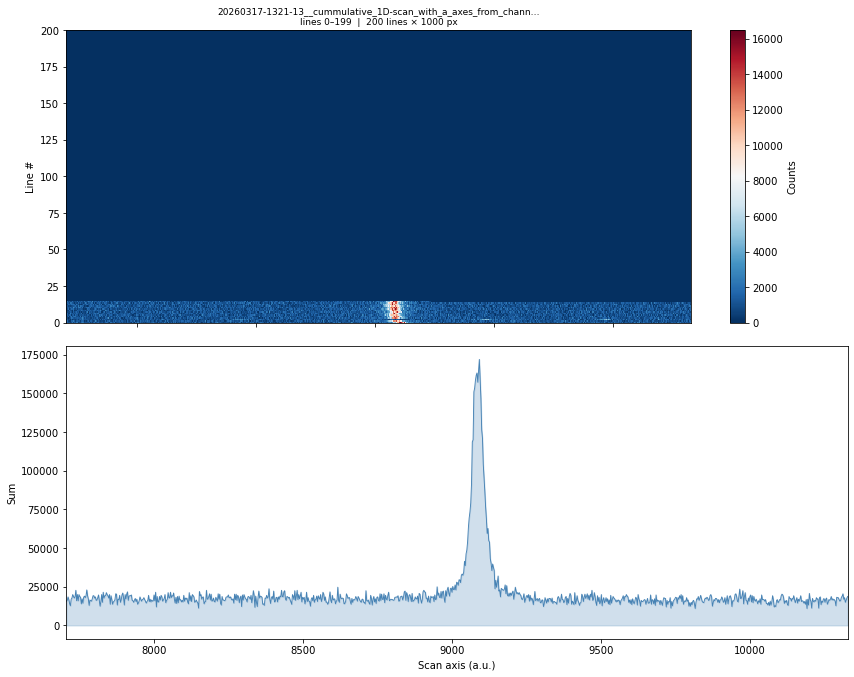

  max=16500  mean=101.74  shape=(200, 1000)


c:\Users\yy3\Anaconda3\lib\site-packages\ipykernel_launcher.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


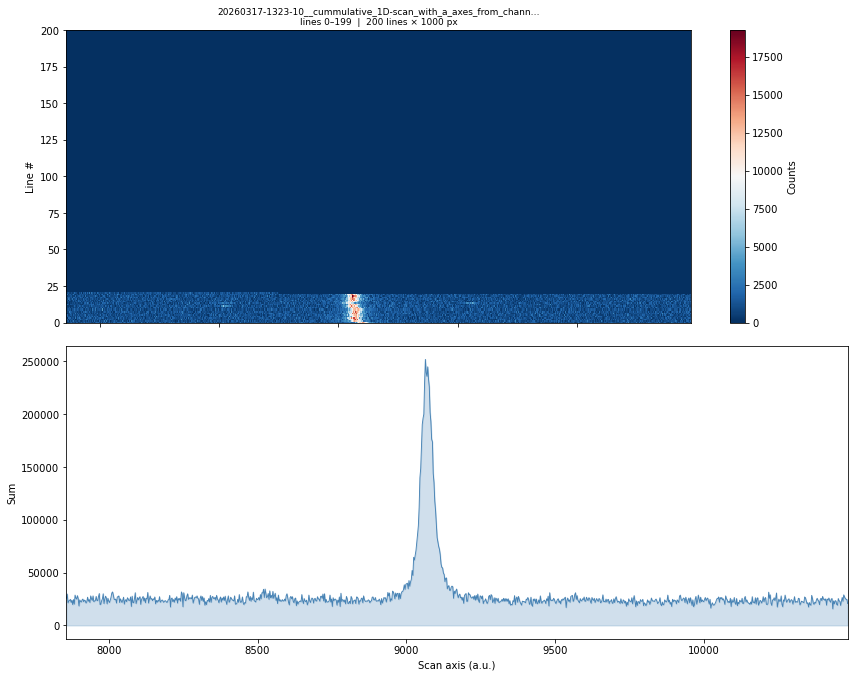

  max=19250  mean=144.56  shape=(200, 1000)


c:\Users\yy3\Anaconda3\lib\site-packages\ipykernel_launcher.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


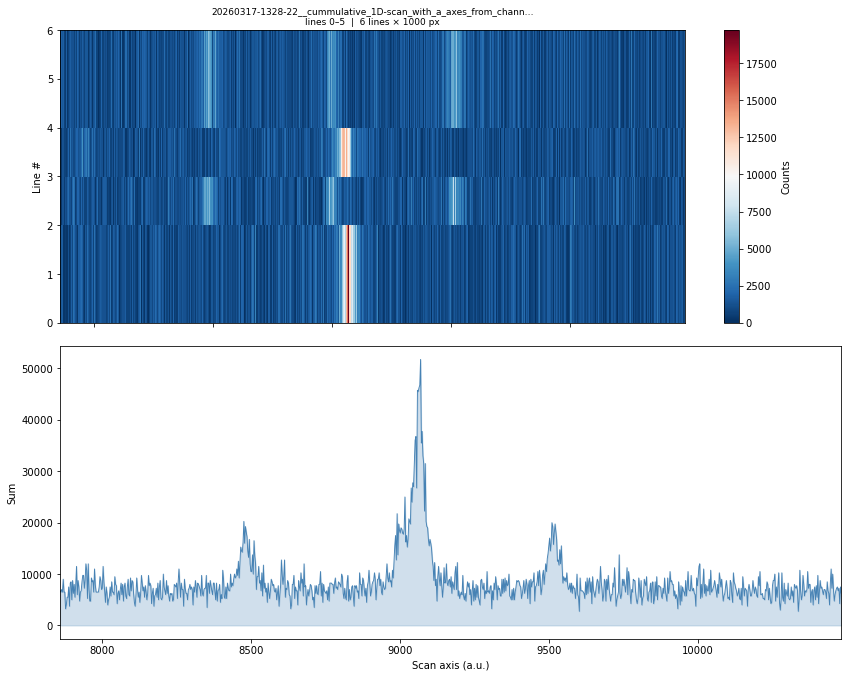

  max=19750  mean=1401.38  shape=(6, 1000)


In [18]:
# ============================================================
#  MAIN PLOT  –  one figure per file
# ============================================================
for fname in FILES:
    lr        = LINE_RANGES.get(fname, [None, None])
    line_start, line_end = lr

    try:
        raw, f_ax, meta, x_label = load_scan(fname, line_start, line_end)
    except Exception as e:
        print(f'Could not load {fname}: {e}')
        continue

    n_lines, n_px = raw.shape
    summed = raw.sum(axis=0)

    # ---- figure layout ----
    n_rows   = 2 if SHOW_SUMMED else 1
    h_ratios = [1, 1] if SHOW_SUMMED else [1]
    fig_h    = FIG_HEIGHT_PER_FILE * (1.4 if SHOW_SUMMED else 1)

    fig = plt.figure(figsize=(FIG_WIDTH, fig_h))
    gs  = gridspec.GridSpec(n_rows, 1, figure=fig, height_ratios=h_ratios, hspace=0.08)

    # ---- 2D waterfall ----
    ax0 = fig.add_subplot(gs[0])
    im  = ax0.imshow(
        raw,
        aspect        = ASPECT,
        origin        = 'lower',
        cmap          = CMAP,
        vmin          = VMIN,
        vmax          = VMAX,
        interpolation = INTERPOLATION,
        extent        = [f_ax[0], f_ax[-1], (line_start or 0), (line_start or 0) + n_lines],
    )
    plt.colorbar(im, ax=ax0, label='Counts')

    # Title: short filename + line range info
    short = fname[:60] + '…' if len(fname) > 60 else fname
    line_info = f'lines {line_start or 0}–{(line_start or 0) + n_lines - 1}'
    ax0.set_title(f'{short}\n{line_info}  |  {n_lines} lines × {n_px} px', fontsize=9)
    ax0.set_ylabel('Line #')
    if not SHOW_SUMMED:
        ax0.set_xlabel(x_label)
    else:
        ax0.tick_params(labelbottom=False)

    # ---- summed spectrum ----
    if SHOW_SUMMED:
        ax1 = fig.add_subplot(gs[1], sharex=ax0)
        ax1.plot(f_ax, summed, color='steelblue', lw=0.9)
        ax1.fill_between(f_ax, summed, alpha=0.25, color='steelblue')
        ax1.set_ylabel('Sum')
        ax1.set_xlabel(x_label)
        ax1.margins(x=0)

    plt.tight_layout()
    plt.show()
    print(f'  max={raw.max():.0f}  mean={raw.mean():.2f}  shape={raw.shape}')

---
## Interactive line-range explorer (optional)

Run the cell below to get `ipywidgets` sliders for a single file.  
Requires `pip install ipywidgets` and either `jupyter nbextension enable --py widgetsnbextension` or a modern JupyterLab.

In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- choose which file to explore interactively ----
INTERACTIVE_FILE = FILES[0]

_raw_full, _f_ax, _meta, _x_label = load_scan(INTERACTIVE_FILE)
NLINES_FULL = _raw_full.shape[0]

sl_start = widgets.IntSlider(value=0,          min=0, max=NLINES_FULL-1, step=1, description='Line start')
sl_end   = widgets.IntSlider(value=NLINES_FULL, min=1, max=NLINES_FULL,   step=1, description='Line end')
dd_file  = widgets.Dropdown(options=FILES, value=INTERACTIVE_FILE, description='File')
dd_cmap  = widgets.Dropdown(options=['hot','inferno','viridis','plasma','gray','RdBu_r'], value=CMAP, description='Colormap')
out      = widgets.Output()

def _reload_file(change):
    global _raw_full, _f_ax, _meta, _x_label, NLINES_FULL
    _raw_full, _f_ax, _meta, _x_label = load_scan(dd_file.value)
    NLINES_FULL = _raw_full.shape[0]
    sl_start.max = NLINES_FULL - 1
    sl_end.max   = NLINES_FULL
    sl_end.value = NLINES_FULL
    _update(None)

def _update(change):
    s, e = sl_start.value, sl_end.value
    if s >= e:
        return
    raw   = _raw_full[s:e, :]
    summed = raw.sum(axis=0)

    with out:
        clear_output(wait=True)
        fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(FIG_WIDTH, FIG_HEIGHT_PER_FILE*1.4),
                                        gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
        im = ax0.imshow(raw, aspect='auto', origin='lower', cmap=dd_cmap.value,
                        interpolation='none',
                        extent=[_f_ax[0], _f_ax[-1], s, e])
        # plt.colorbar(im, ax=ax0, label='Counts')
        ax0.set_title(f'{dd_file.value[:70]}\nlines {s}–{e-1}  ({e-s} lines × {raw.shape[1]} px)', fontsize=8)
        ax0.set_ylabel('Line #')
        ax0.tick_params(labelbottom=False)

        ax1.plot(_f_ax, summed, color='steelblue', lw=0.9)
        ax1.fill_between(_f_ax, summed, alpha=0.25, color='steelblue')
        ax1.set_ylabel('Sum')
        ax1.set_xlabel(_x_label)
        ax1.margins(x=0)
        plt.tight_layout()
        plt.show()

dd_file.observe(_reload_file, names='value')
sl_start.observe(_update, names='value')
sl_end.observe(_update, names='value')
dd_cmap.observe(_update, names='value')

display(widgets.HBox([dd_file, dd_cmap]),
        widgets.HBox([sl_start, sl_end]),
        out)
_update(None)

Output()